In [ ]:
from google.colab import files

uploaded = files.upload()

Saving walmart.xlsx to walmart.xlsx


In [ ]:
import pandas as pd
df=pd.read_excel("walmart.xlsx")

In [ ]:
df.head()

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714
1,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694
2,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.280,4,1.9656
3,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152
4,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
df = pd.read_excel("walmart.xlsx")

In [ ]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Customer Name,0
Country,0
City,0
State,0
Category,0
Product Name,0
Sales,0


In [ ]:
df.drop_duplicates(inplace=True)
df.isnull().sum()


,0
Order ID,0
Order Date,0
Ship Date,0
Customer Name,0
Country,0
City,0
State,0
Category,0
Product Name,0
Sales,0


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['Weekday'] = df['Order Date'].dt.dayofweek

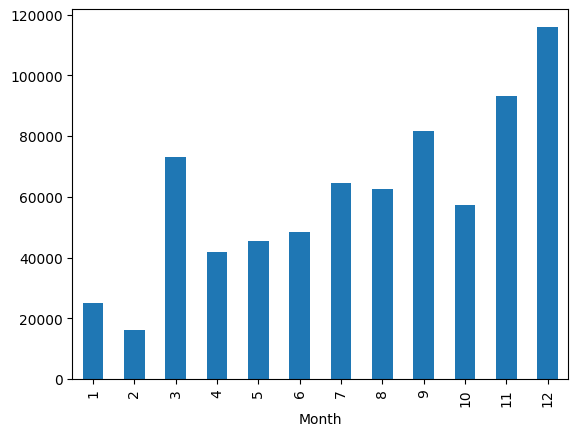

In [ ]:
monthly = df.groupby('Month')['Sales'].sum()

monthly.plot(kind='bar')
plt.show()

In [ ]:
X = df[['Year','Month','Day','Weekday']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestRegressor()

model.fit(X_train, y_train)
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 299.27085524593764
RMSE: 538.0714982148373


In [ ]:
future = pd.DataFrame({
    "Year":[2026],
    "Month":[8],
    "Day":[1],
    "Weekday":[5]
})

future_prediction = model.predict(future)

print(future_prediction)

[217.62734995]
